## Notebook: Downstream Segmentation with TerraTorch

In this notebook, we use the EO embeddings generated in the previous notebook for a downstream burn scar segmentation task.

Instead of fine-tuning a full foundation model, we train a small segmentation decoder on top of the saved TerraMind embeddings using TerraTorch's `IdentityBackbone`. We start from the TerraMind embeddings generated in the previous notebook.


In [25]:
from pathlib import Path
import albumentations
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import torch
import lightning.pytorch as pl
import terratorch
from terratorch.datasets.utils import to_pca_rgb

import warnings
warnings.filterwarnings('ignore')

### 1. Checking Data (to be updated)

This notebook requires the HLS Burn Scars labels and precomputed TerraMind embeddings.


In [26]:
root = Path("hls_burn_scars")
if not root.is_dir():
    root = Path("../01_TerraTorch_Embeddings/hls_burn_scars")

dataset_path = root / "data"
embedding_path = root / "embeddings_terramind" / "layer_00"

dataset_files = list(dataset_path.glob("*_merged.tif")) if dataset_path.is_dir() else []
embedding_files = list(embedding_path.glob("*_embedding.tif")) if embedding_path.is_dir() else []

if not dataset_files or not embedding_files:
    raise RuntimeError(
        "Required data not found. Please check the paths or generate embeddings in "
        "`embedding_generation_burnscars.ipynb`."
    )

print(f"Found {len(dataset_files)} images and {len(embedding_files)} embeddings.")


Found 804 images and 804 embeddings.


### 2. Building the Datamodule

As in the first notebook, this step defines where to find the data. Our needed data now is: Embedding GeoTIFF files as inputs, label masks as targets, and train/val/test split files that define which samples are used for which training and testing stage.

We pass the embedding and mask locations as `data_root` and `label_data_root`, while `img_grep` and `label_grep` specify how matching files are found.

We set `embedding_input=True` because the inputs now are pretrained embeddings rather than raw satellite bands. During training, we apply simple spatial augmentations with `albumentations.D4()` to diversify the training data.

Finally, `datamodule.setup("fit")` initializes the training and validation datasets and prepares the dataloaders.

In [27]:
from terratorch.datamodules import GenericNonGeoSegmentationDataModule

datamodule = GenericNonGeoSegmentationDataModule(
    batch_size=8,
    num_workers=2,
    num_classes=2,
    check_stackability=False,

    train_data_root=embedding_path,
    val_data_root=embedding_path,
    test_data_root=embedding_path,

    train_label_data_root=dataset_path,
    val_label_data_root=dataset_path,
    test_label_data_root=dataset_path,

    img_grep="*_embedding.tif",
    label_grep="*.mask.tif",

    train_split=root / "splits/train.txt",
    val_split=root / "splits/val.txt",
    test_split=root / "splits/test.txt",

    no_label_replace=-1,
    embedding_input=True,

    train_transform=[
        albumentations.D4(), # Random flips and rotations
        albumentations.pytorch.transforms.ToTensorV2(),
    ],
    val_transform=None,
    test_transform=None,
)

datamodule.setup("fit")

Before training, we inspect an embedding/label pair to confirm that the datamodule loads the right files.

Length training dataset: 524


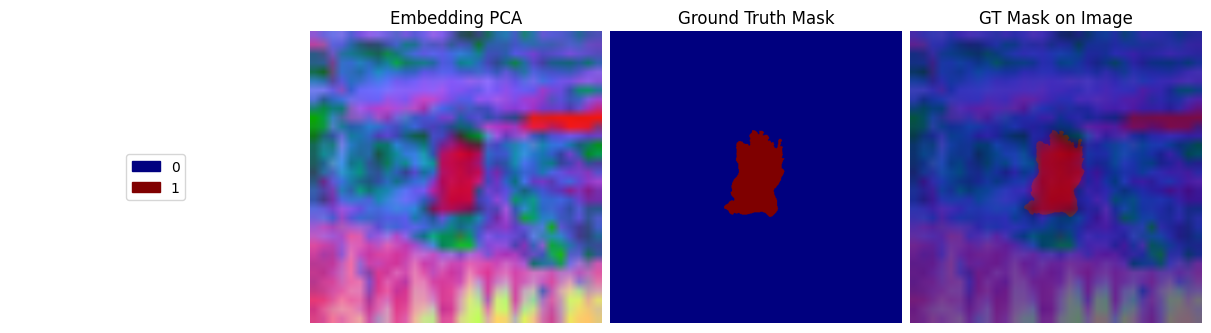

In [28]:
# Inspect one sample
train_dataset = datamodule.train_dataset
print(f"Length training dataset: {len(train_dataset)}")

_ = train_dataset.plot(train_dataset[0])


### 3. Building the Segmentation Task

The main idea is that we train directly on pretrained embeddings instead of raw satellite bands. Using `IdentityBackbone` means the model simply forwards the saved embeddings to the decoder, without running a large foundation model during training or inference.

<div style="text-align: center;">
  <img src="../01_TerraTorch_Embeddings/FM_vs_embedding.png" width="850">
</div>

Our embeddings are stored as spatial GeoTIFF tensors, so they can be passed directly to a convolutional upsampling decoder (`FCNDecoder`) for dense pixelwise segmentation. Most other settings are standard TerraTorch segmentation settings that define the decoder configuration, loss, optimizer, and class definitions. You can check out other TerraTorch resources for more details and recommended default configurations for different types of tasks.

For embedding workflows, it is also important to set `rescale=False` and provide the expected output resolution via `image_size_out`, as embeddings and outputs do not share the same spatial resolution.

In [15]:
from terratorch.tasks import SemanticSegmentationTask

model = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",
    model_args={
        # IdentityBackbone passes embeddings directly to the decoder
        "backbone": "IdentityBackbone",
        "backbone_out_channels": [384],
        "necks": [{"name": "SelectIndices", "indices": [0]}],

        "decoder": "FCNDecoder",
        "decoder_channels": 32,
        "head_dropout": 0.1,
        "head_channel_list": [32],
        "num_classes": 2,

        # Important for pixelwise embedding workflows
        "rescale": False,
        "image_size_out": (512, 512),
    },
    loss="dice",
    optimizer="AdamW",
    ignore_index=-1,
    lr=1e-4,
    freeze_decoder=False,
    class_names=["not burned", "burned"],
)


We keep training intentionally short, just enough to try out the workflow end to end.

In [ ]:
pl.seed_everything(0)

best_ckpt_path = "output/terramind_embeddings_burnscars/best-val.ckpt"
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath="output/terramind_embeddings_burnscars/",
    filename="best-val",
    save_weights_only=True,
)

trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    precision="bf16-mixed",
    max_epochs=3,
    callbacks=[checkpoint_callback],
    default_root_dir="output/terramind_embeddings_burnscars/",
)


In [ ]:
# Train the downstream task model
trainer.fit(model, datamodule=datamodule)

### 4. Inspecting Results

We now compare the predicted segmentation mask with the ground truth mask. Since this training run is intentionally short, the goal here is mainly to verify that the workflow and predictions look reasonable. We will run longer trainings later in Part 4 of the workshop.

The helper below plots the embedding PCA view, ground truth mask, and predicted mask side by side.

In [18]:
def plot_sample(sample):
    embedding = sample["image"].cpu().numpy()
    label_mask = sample["mask"].cpu().numpy()
    prediction_mask = sample["prediction"]

    if isinstance(prediction_mask, torch.Tensor):
        prediction_mask = prediction_mask.cpu().numpy()

    emb_rgb, _, _ = to_pca_rgb(embedding, step=1)

    num_classes = 2
    class_names = ["Not Burned", "Burned"]
    norm = matplotlib.colors.Normalize(vmin=0, vmax=num_classes - 1)
    cmap = plt.get_cmap("jet")

    fig, ax = plt.subplots(1, 4, figsize=(12, 4))

    ax[0].axis("off")
    handles = [
        Rectangle((0, 0), 1, 1, color=cmap(norm(i)))
        for i in range(num_classes)
    ]
    ax[0].legend(handles, class_names, loc="center")

    ax[1].imshow(emb_rgb)
    ax[1].set_title("Embedding PCA")
    ax[1].axis("off")

    ax[2].imshow(label_mask, cmap=cmap, norm=norm)
    ax[2].set_title("Ground Truth Mask")
    ax[2].axis("off")

    ax[3].imshow(prediction_mask, cmap=cmap, norm=norm)
    ax[3].set_title("Predicted Mask")
    ax[3].axis("off")

    fig.tight_layout()
    plt.show()

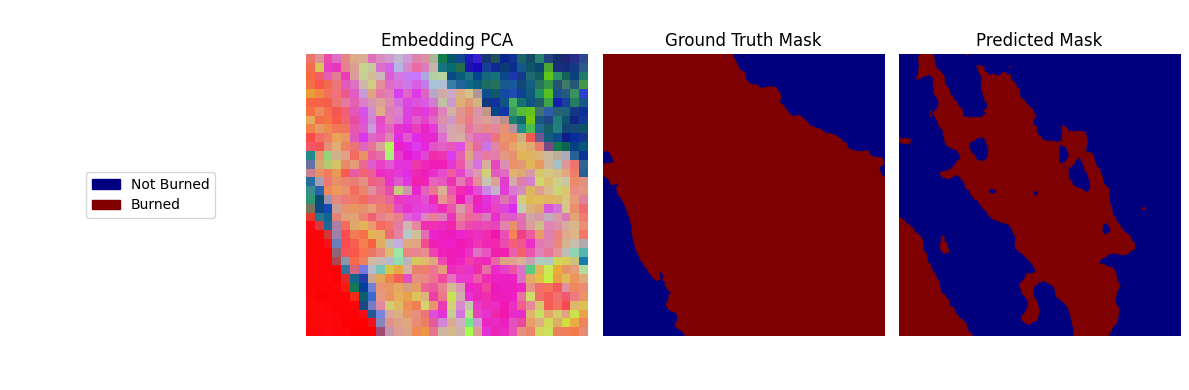

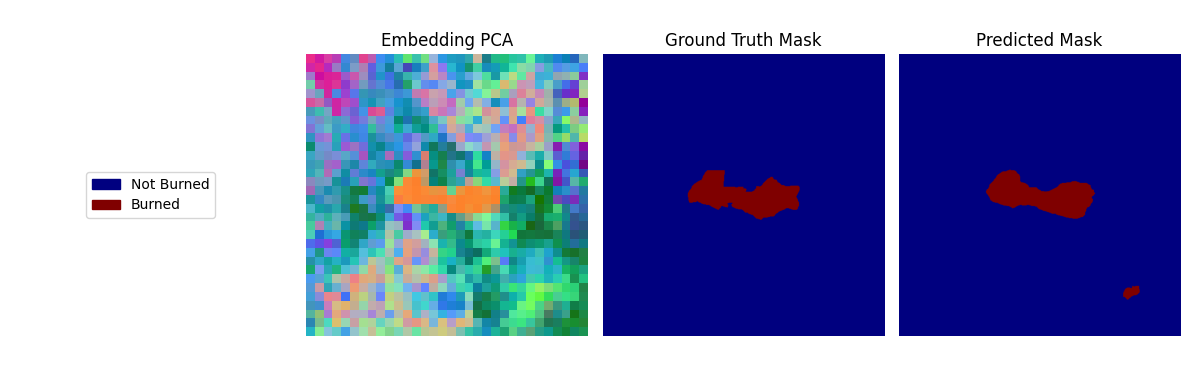

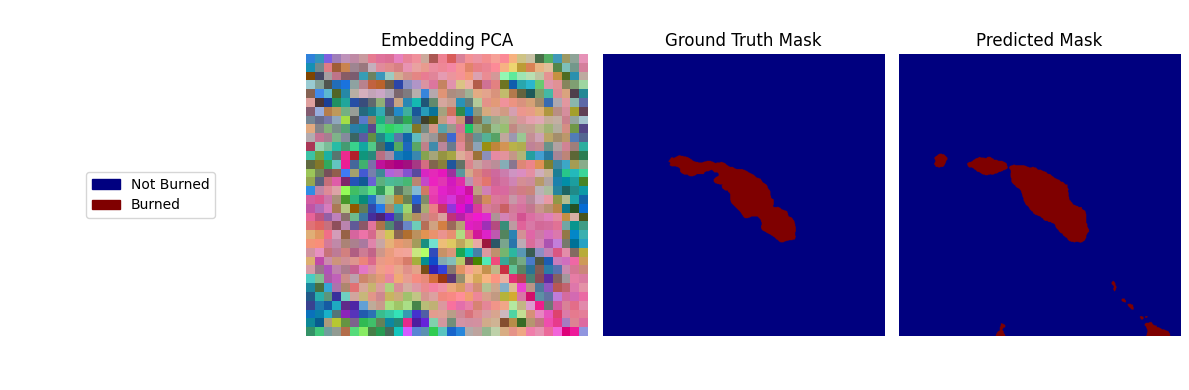

In [24]:
# Use the trained model for prediction and visualization
model = terratorch.tasks.SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_factory=model.hparams.model_factory,
    model_args=model.hparams.model_args,
).to("cpu")

model.eval()

datamodule.setup("test")

batch = next(iter(datamodule.test_dataloader()))

with torch.no_grad():
    outputs = model(batch["image"])
    preds = outputs.output.argmax(dim=1).cpu().numpy()

# Plot a few samples
for i in range(1, 4):
    plot_sample({
        "image": batch["image"][i],
        "mask": batch["mask"][i],
        "prediction": preds[i],
    })